# TSF vs CPS vs TSCQR vs MSCP — dados discretos reais

Comparação entre **TSF**, **CPS**, **TSCQR** e **MSCP** em M5 e UCI Bike Sharing. Todos são avaliados fora da amostra, com alvos inteiros e sem dados sintéticos.

In [1]:
from importlib.metadata import version
from pathlib import Path
from time import perf_counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from lightgbm import LGBMRegressor
from mlforecast import MLForecast
from sklearn.ensemble import HistGradientBoostingRegressor

from tinyshift.forecasting import (
    NegativeBinomialFamily,
    TwoStageForecasterWrapper,
    WeibullFamily,
)
from tinyconformal.series import (
    ConformalDistributionTimeSeriesRegressor,
    ConformalQuantileTimeSeriesRegressor,
    ContinuousTimeSeriesConformalPredictiveSystem,
    DiscreteTimeSeriesConformalPredictiveSystem,
)

SEED = 42
H = 14
N_WINDOWS = 12
LEVEL = 0.90
DATA_DIR = Path("data/tsf_cps")
DATA_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

print({"tinyshift": version("tinyshift"), "tinyconformal": version("tinyconformal")})

{'tinyshift': '1.7.7', 'tinyconformal': '0.5.4'}


In [2]:
def make_forecaster(freq, lags):
    model = LGBMRegressor(
        n_estimators=120, learning_rate=0.05, num_leaves=15,
        verbosity=-1, random_state=SEED, n_jobs=1,
    )
    return MLForecast(models={"LGBM": model}, freq=freq, lags=lags)


def make_quantile_forecaster(freq, lags, level=LEVEL):
    alpha = 1-level
    models = {
        "LGBM": LGBMRegressor(
            n_estimators=120, learning_rate=0.05, num_leaves=15,
            verbosity=-1, random_state=SEED, n_jobs=1,
        ),
        "LGBM-lo-90": LGBMRegressor(
            objective="quantile", alpha=alpha/2, n_estimators=120,
            learning_rate=0.05, num_leaves=15, verbosity=-1,
            random_state=SEED, n_jobs=1,
        ),
        "LGBM-hi-90": LGBMRegressor(
            objective="quantile", alpha=1-alpha/2, n_estimators=120,
            learning_rate=0.05, num_leaves=15, verbosity=-1,
            random_state=SEED, n_jobs=1,
        ),
    }
    return MLForecast(models=models, freq=freq, lags=lags)


def fit_tsf(train, freq, lags, family, h=H, n_windows=N_WINDOWS, step_size=None):
    model = TwoStageForecasterWrapper(make_forecaster(freq, lags), distribution=family)
    tic = perf_counter()
    model.fit(
        train, h=h, n_windows=n_windows, step_size=step_size, refit=True
    )
    fit_seconds = perf_counter() - tic
    tic = perf_counter()
    forecast = model.predict_distribution(h=h)
    predict_seconds = perf_counter() - tic
    return model, forecast, fit_seconds, predict_seconds


def fit_cps(
    train, freq, lags, discrete, h=H, n_windows=N_WINDOWS, step_size=None
):
    cls = (DiscreteTimeSeriesConformalPredictiveSystem if discrete
           else ContinuousTimeSeriesConformalPredictiveSystem)
    model = cls(
        learner=make_forecaster(freq, lags),
        dispersion_learner=HistGradientBoostingRegressor(
            max_iter=80, max_leaf_nodes=8, random_state=SEED
        ),
        horizon=h, n_windows=n_windows, alpha=1-LEVEL,
    )
    tic = perf_counter()
    model.fit(train, step_size=step_size, n_jobs=1)
    fit_seconds = perf_counter() - tic
    tic = perf_counter()
    forecast = model.predict_distribution(h=h)
    predict_seconds = perf_counter() - tic
    return model, forecast, fit_seconds, predict_seconds


def fit_tscqr(train, freq, lags, h=H, n_windows=N_WINDOWS, step_size=None):
    model = ConformalQuantileTimeSeriesRegressor(
        learner=make_quantile_forecaster(freq, lags), horizon=h,
        intervals=("LGBM-lo-90", "LGBM-hi-90"), n_windows=n_windows,
    )
    tic = perf_counter()
    model.fit(train, step_size=step_size, n_jobs=1)
    fit_seconds = perf_counter() - tic
    tic = perf_counter()
    forecast = model.predict_interval(h=h)
    predict_seconds = perf_counter() - tic
    return model, forecast, fit_seconds, predict_seconds


def fit_mscp(train, freq, lags, h=H, n_windows=N_WINDOWS, step_size=None):
    model = ConformalDistributionTimeSeriesRegressor(
        learner=make_forecaster(freq, lags), horizon=h,
        n_windows=n_windows, alpha=1-LEVEL,
    )
    tic = perf_counter()
    model.fit(train, step_size=step_size, n_jobs=1)
    fit_seconds = perf_counter() - tic
    tic = perf_counter()
    forecast = model.predict_interval(h=h)
    predict_seconds = perf_counter() - tic
    return model, forecast, fit_seconds, predict_seconds


def prediction_table(forecast, test, level=LEVEL):
    base = forecast.to_frame().copy()
    intervals = forecast.interval(level)
    quantiles = forecast.ppf([0.5])
    out = base.merge(test[["unique_id", "ds", "y"]], on=["unique_id", "ds"], validate="one_to_one")
    # APIs preservam a ordem do painel e nomeiam explicitamente os outputs.
    lo_col = next(c for c in intervals if "-lo-" in c)
    hi_col = next(c for c in intervals if "-hi-" in c)
    median_col = next(c for c in quantiles if "-q-50" in c)
    out["lower"] = intervals[lo_col].to_numpy()
    out["upper"] = intervals[hi_col].to_numpy()
    out["median"] = quantiles[median_col].to_numpy()
    return out


def conformal_prediction_table(forecast, test, method):
    out = forecast.merge(
        test[["unique_id", "ds", "y"]],
        on=["unique_id", "ds"], validate="one_to_one",
    )
    if method == "TSCQR":
        out["lower"] = out["LGBM-lo-90-cqr"]
        out["upper"] = out["LGBM-hi-90-cqr"]
        out["median"] = out["LGBM"]
    elif method == "MSCP":
        out["lower"] = out["LGBM-lo-90"]
        out["upper"] = out["LGBM-hi-90"]
        out["median"] = out["LGBM"]
    else:
        raise ValueError(f"Método conformal desconhecido: {method}")
    return out


def metrics(table, method, dataset, fit_seconds, predict_seconds, level=LEVEL):
    y = table.y.to_numpy(float)
    lo, hi, pred = (table[c].to_numpy(float) for c in ["lower", "upper", "median"])
    alpha = 1-level
    covered = (y >= lo) & (y <= hi)
    winkler = (hi-lo) + (2/alpha)*(lo-y)*(y < lo) + (2/alpha)*(y-hi)*(y > hi)
    return {
        "dataset": dataset, "method": method,
        "RMSE_mediana": np.sqrt(np.mean((y-pred)**2)),
        "MAE_mediana": np.mean(np.abs(y-pred)),
        "cobertura_90": covered.mean(), "largura_media_90": np.mean(hi-lo),
        "Winkler_90": np.mean(winkler), "fit_s": fit_seconds,
        "predict_s": predict_seconds, "n_teste": len(y),
    }


def plot_intervals(tables, title):
    fig, axes = plt.subplots(len(tables), 1, figsize=(13, 3.6*len(tables)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, (name, tab) in zip(axes, tables.items()):
        one = tab[tab.unique_id == tab.unique_id.iloc[0]]
        ax.plot(one.ds, one.y, "o-", color="black", label="observado", ms=3)
        ax.plot(one.ds, one["median"], color="C0", label="mediana")
        ax.fill_between(one.ds, one.lower, one.upper, alpha=.25, label="intervalo 90%")
        ax.set_title(name); ax.legend(ncol=3)
    fig.suptitle(title, y=1.01); plt.tight_layout()


def temporal_split(df, h=H):
    df = df.sort_values(["unique_id", "ds"]).reset_index(drop=True)
    test = df.groupby("unique_id", group_keys=False).tail(h)
    train = df.drop(test.index).reset_index(drop=True)
    return train, test.reset_index(drop=True)

In [3]:
M5_URL = "https://www.kaggle.com/competitions/m5-forecasting-accuracy/data"
M5_MIRROR = "https://huggingface.co/datasets/kashif/M5/resolve/main/sales_train_evaluation.csv"
BIKE_URL = "https://raw.githubusercontent.com/udacity/deep-learning/master/first-neural-network/Bike-Sharing-Dataset/hour.csv"


def load_m5(n_series=5, n_days=700):
    """Baixa a competição oficial (aceite das regras/login Kaggle pode ser necessário)."""
    target = DATA_DIR / "m5" / "sales_train_evaluation.csv"
    if not target.exists():
        import kagglehub
        try:
            downloaded = Path(kagglehub.competition_download("m5-forecasting-accuracy"))
            candidates = list(downloaded.rglob("sales_train_evaluation.csv"))
        except Exception as exc:
            warnings.warn(f"Kaggle indisponível ({type(exc).__name__}); usando espelho público Hugging Face.")
            candidates = []
        source = candidates[0] if candidates else M5_MIRROR
        target.parent.mkdir(parents=True, exist_ok=True)
        if isinstance(source, Path):
            target.write_bytes(source.read_bytes())
        else:
            from urllib.request import urlretrieve
            urlretrieve(source, target)
    wide = pd.read_csv(target, nrows=n_series)
    day_cols = [c for c in wide if c.startswith("d_")][-n_days:]
    long = wide[["id", *day_cols]].melt("id", var_name="day", value_name="y")
    long["ds"] = pd.Timestamp("2011-01-29") + pd.to_timedelta(long.day.str[2:].astype(int)-1, unit="D")
    return long.rename(columns={"id": "unique_id"})[["unique_id", "ds", "y"]].astype({"y": int})


def load_bike():
    raw = pd.read_csv(BIKE_URL)
    raw["ds"] = pd.to_datetime(raw.dteday) + pd.to_timedelta(raw.hr, unit="h")
    # Maior trecho horário contíguo: não preenche nem sintetiza horas ausentes.
    raw = raw.sort_values("ds")
    run = raw.ds.diff().ne(pd.Timedelta(hours=1)).cumsum()
    raw = raw[run.eq(run.value_counts().idxmax())].tail(24*180)
    return pd.DataFrame({"unique_id": "CapitalBikeshare", "ds": raw.ds, "y": raw.cnt.astype(int)})


datasets = {"M5 (5 itens)": load_m5(), "UCI Bike Sharing": load_bike()}
for name, frame in datasets.items():
    print(name, frame.shape, frame.ds.min(), frame.ds.max(), "inteiros:", np.all(frame.y == np.floor(frame.y)))

M5 (5 itens) (3500, 3) 2014-06-23 00:00:00 2016-05-22 00:00:00 inteiros: True
UCI Bike Sharing (4320, 3) 2012-05-02 01:00:00 2012-10-29 00:00:00 inteiros: True


## Benchmark temporal

A última janela é teste; todas as janelas anteriores são treino/calibração. O mesmo LightGBM, lags, horizonte, 12 janelas e sobreposição são usados por TSF, CPS, TSCQR e MSCP. `step_size=3` em AirPassengers e `step_size=7` nas demais séries; como ambos são menores que `H=14`, as janelas se sobrepõem.

In [4]:
results, predictions = [], {}
for dataset_name, df in datasets.items():
    freq = "MS" if dataset_name == "AirPassengers" else ("h" if "Bike" in dataset_name else "D")
    lags = [1, 12] if freq == "MS" else ([1, 24, 168] if freq == "h" else [1, 7, 28])
    step_size = 3 if dataset_name == "AirPassengers" else 7
    train, test = temporal_split(df)

    tsf, tsf_fc, tsf_fit, tsf_pred = fit_tsf(
        train, freq, lags, NegativeBinomialFamily(), step_size=step_size
    )
    cps, cps_fc, cps_fit, cps_pred = fit_cps(
        train, freq, lags, discrete=True, step_size=step_size
    )
    tscqr, tscqr_fc, tscqr_fit, tscqr_pred = fit_tscqr(
        train, freq, lags, step_size=step_size
    )
    mscp, mscp_fc, mscp_fit, mscp_pred = fit_mscp(
        train, freq, lags, step_size=step_size
    )
    tsf_tab = prediction_table(tsf_fc, test)
    cps_tab = prediction_table(cps_fc, test)
    tscqr_tab = conformal_prediction_table(tscqr_fc, test, "TSCQR")
    mscp_tab = conformal_prediction_table(mscp_fc, test, "MSCP")
    predictions[(dataset_name, "TSF")] = tsf_tab
    predictions[(dataset_name, "CPS")] = cps_tab
    predictions[(dataset_name, "TSCQR")] = tscqr_tab
    predictions[(dataset_name, "MSCP")] = mscp_tab
    results += [
        metrics(tsf_tab, "TSF", dataset_name, tsf_fit, tsf_pred),
        metrics(cps_tab, "CPS", dataset_name, cps_fit, cps_pred),
        metrics(tscqr_tab, "TSCQR", dataset_name, tscqr_fit, tscqr_pred),
        metrics(mscp_tab, "MSCP", dataset_name, mscp_fit, mscp_pred),
    ]

resultados = pd.DataFrame(results)
display(resultados.round(4))
display(resultados.pivot(index="dataset", columns="method",
                         values=["RMSE_mediana", "cobertura_90", "largura_media_90", "Winkler_90", "fit_s"]).round(4))

/home/heylucasleao/forecasting/.venv/lib/python3.10/site-packages/tinyconformal/series/mscp.py:244: RuntimeWarning: The requested two-sided coverage is not attainable for ConformalDistributionTimeSeriesRegressor with the available calibration sample (n=12); the conformal rank will be clipped to the observed score range.
  return central_conformal_quantile_levels(
/home/heylucasleao/forecasting/.venv/lib/python3.10/site-packages/tinyconformal/series/mscp.py:244: RuntimeWarning: The requested two-sided coverage is not attainable for ConformalDistributionTimeSeriesRegressor with the available calibration sample (n=12); the conformal rank will be clipped to the observed score range.
  return central_conformal_quantile_levels(


,dataset,method,RMSE_mediana,MAE_mediana,cobertura_90,largura_media_90,Winkler_90,fit_s,predict_s,n_teste
0,M5 (5 itens),TSF,1.3093,0.9429,1.0000,4.1714,4.1714,0.8864,0.0260,70
1,M5 (5 itens),CPS,1.3990,1.1286,0.8286,3.8000,7.5143,1.4780,0.0307,70
2,M5 (5 itens),TSCQR,1.1933,0.9703,1.0000,5.2058,5.2058,1.8230,0.0717,70
3,M5 (5 itens),MSCP,1.1933,0.9703,0.8000,3.6657,5.0872,0.6594,0.0264,70
4,UCI Bike Sharing,TSF,203.8932,184.8571,0.1429,315.0000,1497.8571,0.7425,0.0242,14
5,UCI Bike Sharing,CPS,216.5243,198.0714,0.2857,308.9286,2391.7857,1.3961,0.0305,14
6,UCI Bike Sharing,TSCQR,211.9471,192.4657,0.5714,502.9098,613.4769,2.0097,0.0721,14
7,UCI Bike Sharing,MSCP,211.9471,192.4657,0.2857,254.2773,2474.9775,0.7206,0.0247,14


RMSE_mediana                               cobertura_90  \
method                    CPS      MSCP     TSCQR       TSF          CPS   
dataset                                                                    
M5 (5 itens)           1.3990    1.1933    1.1933    1.3093       0.8286   
UCI Bike Sharing     216.5243  211.9471  211.9471  203.8932       0.2857   

                                         largura_media_90                      \
method              MSCP   TSCQR     TSF              CPS      MSCP     TSCQR   
dataset                                                                         
M5 (5 itens)      0.8000  1.0000  1.0000           3.8000    3.6657    5.2058   
UCI Bike Sharing  0.2857  0.5714  0.1429         308.9286  254.2773  502.9098   

                           Winkler_90                                   fit_s  \
method                 TSF        CPS       MSCP     TSCQR        TSF     CPS   
dataset                                                                         
M5 (5 itens)        4.1714     7.5143     5.0872    5.2058     4.1714  1.4780   
UCI Bike Sharing  315.0000  2391.7857  2474.9775  613.4769  1497.8571  1.3961   

                                          
method              MSCP   TSCQR     TSF  
dataset                                   
M5 (5 itens)      0.6594  1.8230  0.8864  
UCI Bike Sharing  0.7206  2.0097  0.7425

## Visualização e síntese

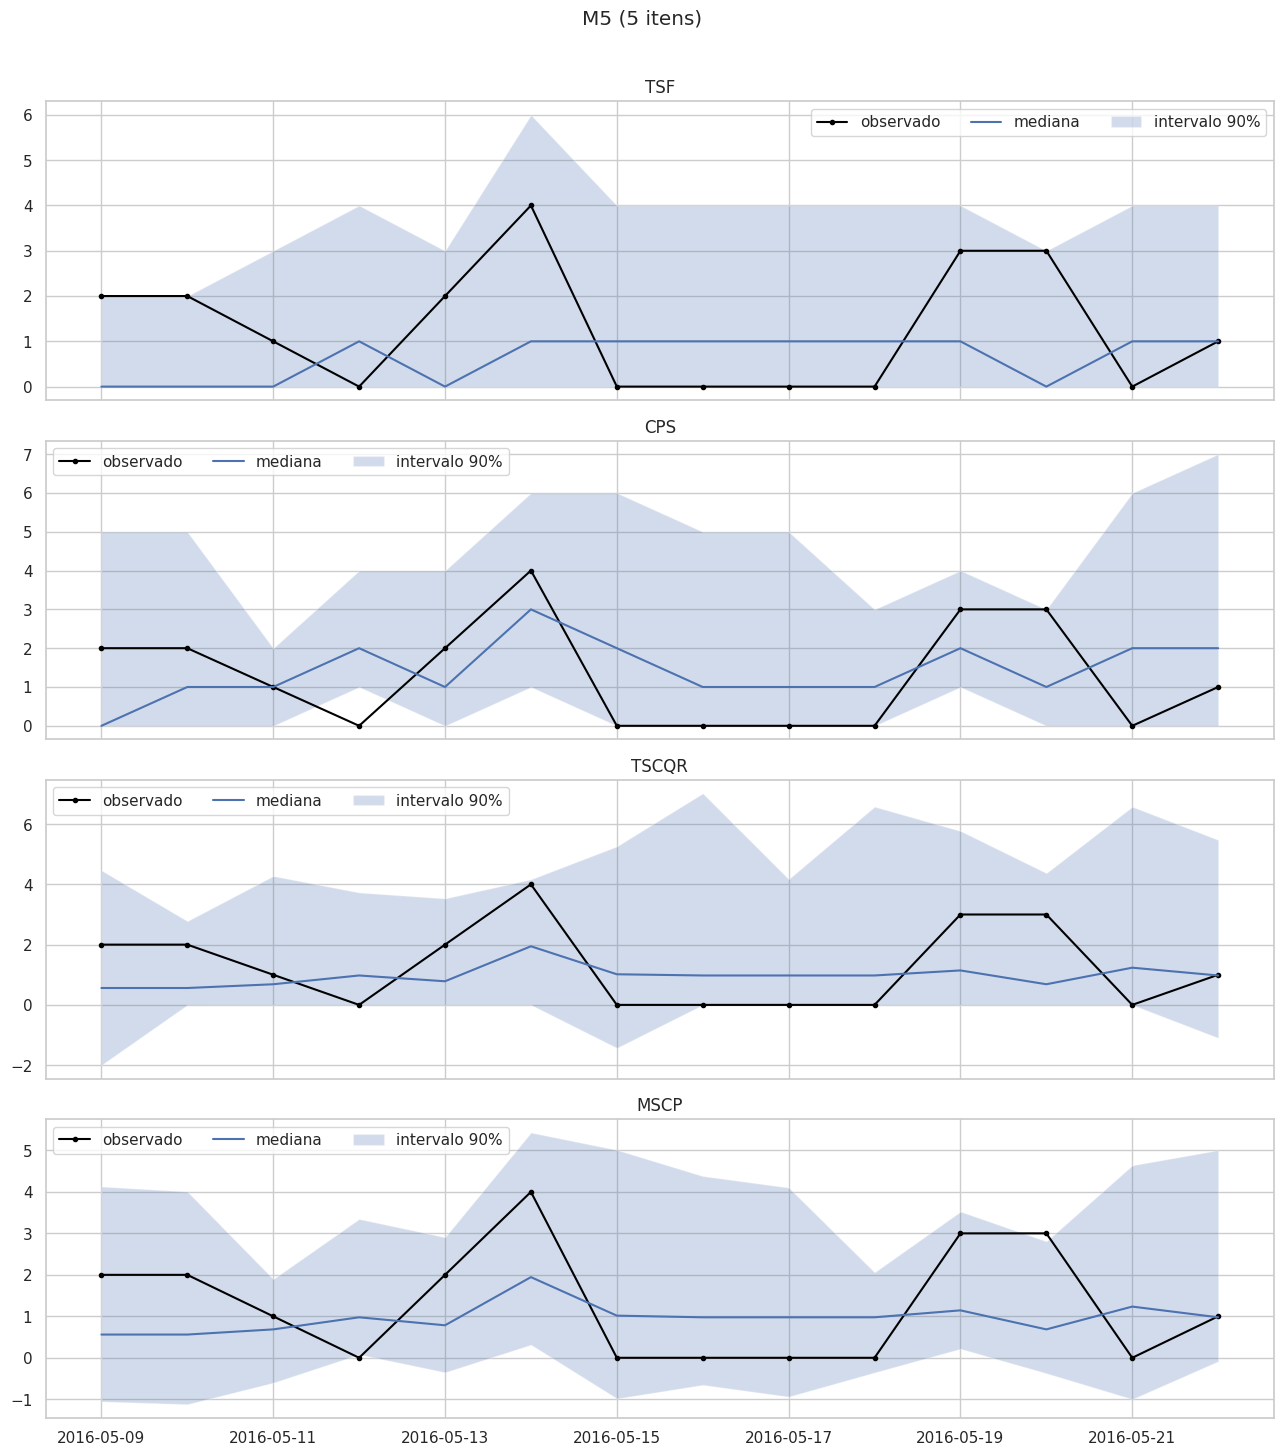

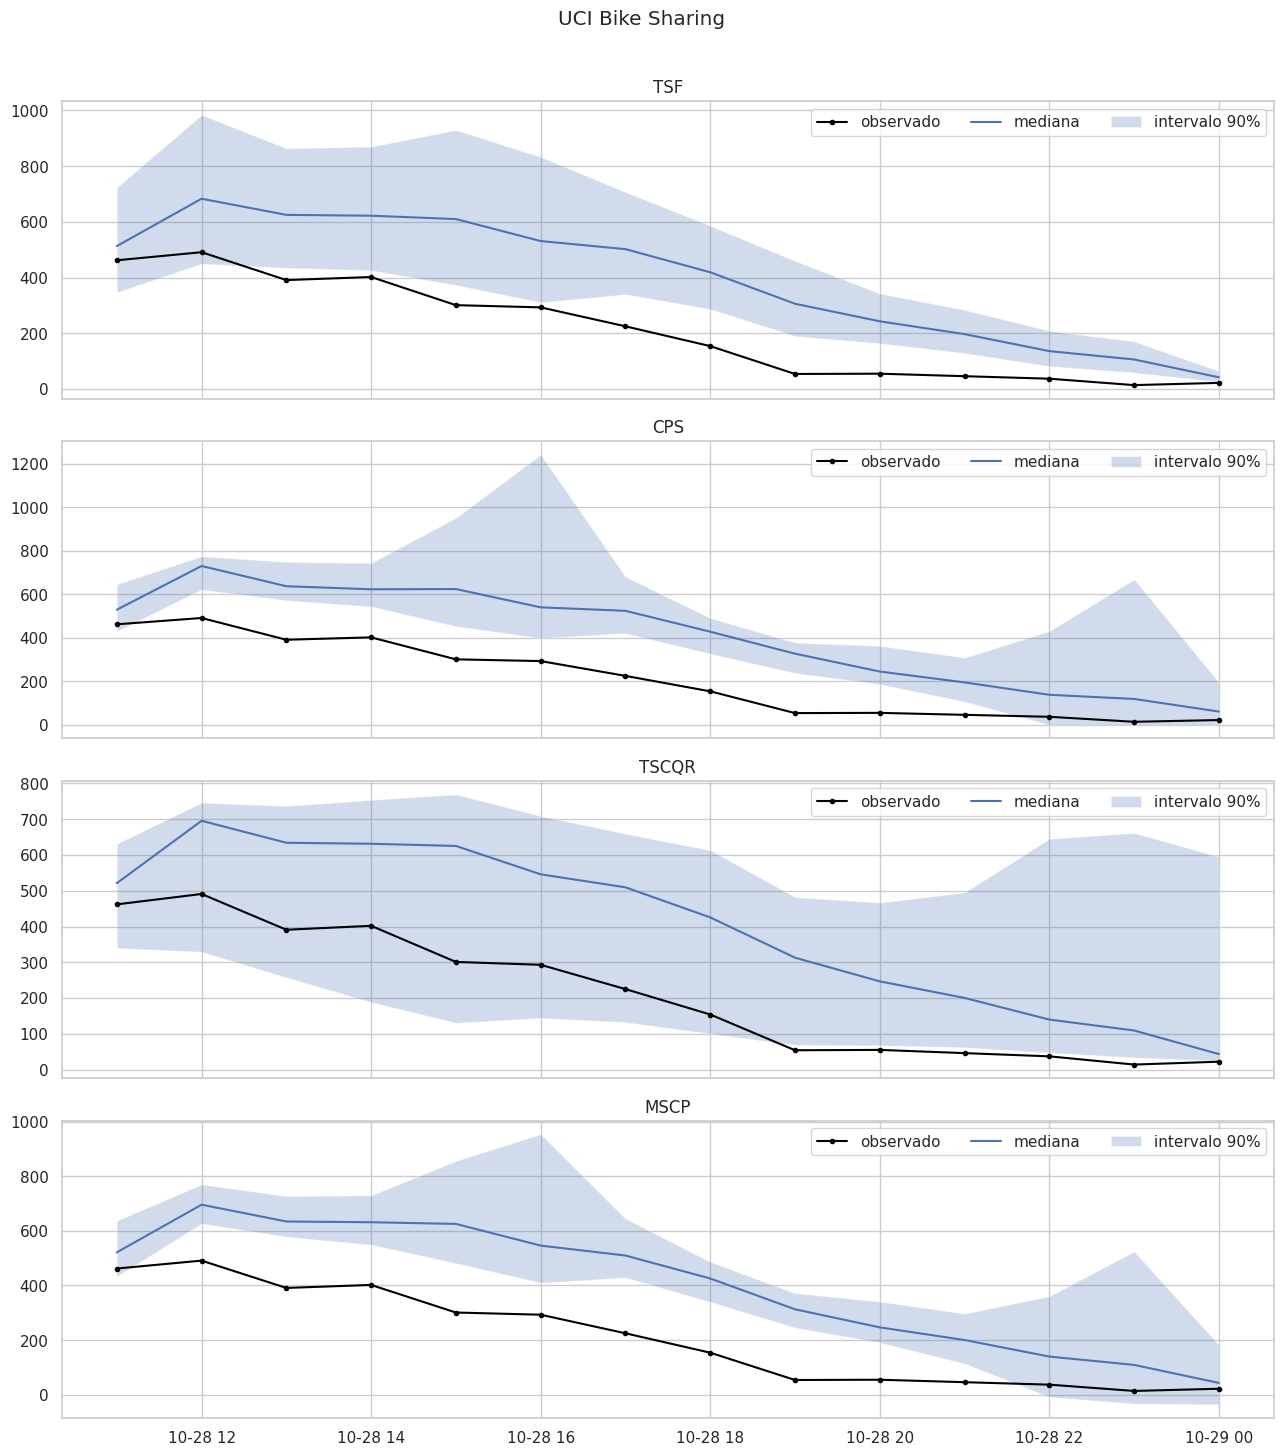

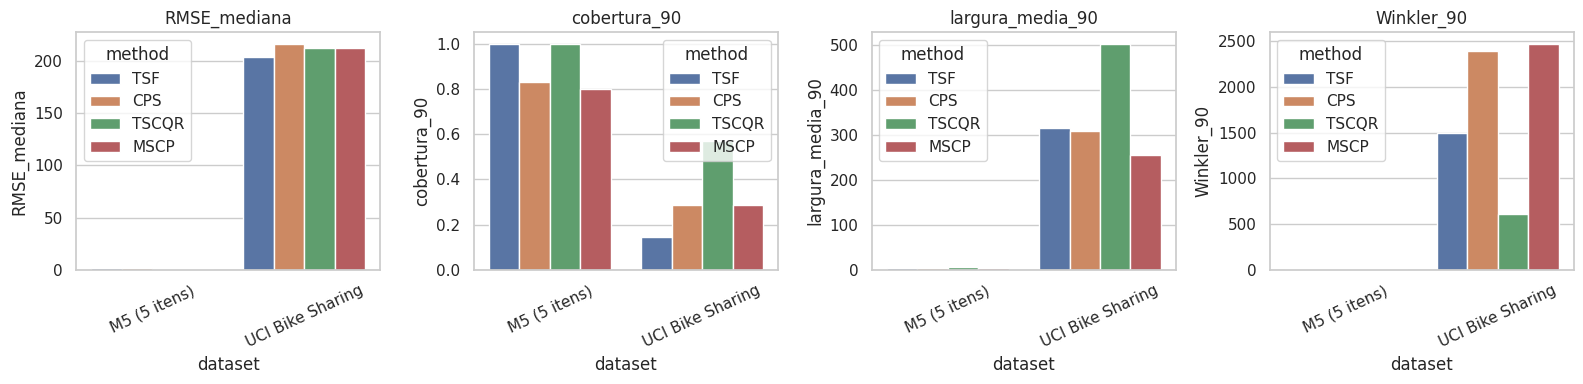

In [5]:
for dataset_name in datasets:
    plot_intervals(
        {method: predictions[(dataset_name, method)] for method in ["TSF", "CPS", "TSCQR", "MSCP"]},
        dataset_name,
    )

metric_cols = ["RMSE_mediana", "cobertura_90", "largura_media_90", "Winkler_90"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, metric in zip(axes, metric_cols):
    sns.barplot(resultados, x="dataset", y=metric, hue="method", ax=ax)
    ax.tick_params(axis="x", rotation=25); ax.set_title(metric)
plt.tight_layout()

In [6]:
def winners(frame):
    rows = []
    for dataset, part in frame.groupby("dataset"):
        target = 0.90
        rows.append({
            "dataset": dataset,
            "menor_RMSE": part.loc[part.RMSE_mediana.idxmin(), "method"],
            "cobertura_mais_próxima_90%": part.loc[(part.cobertura_90-target).abs().idxmin(), "method"],
            "menor_Winkler": part.loc[part.Winkler_90.idxmin(), "method"],
            "fit_mais_rápido": part.loc[part.fit_s.idxmin(), "method"],
        })
    return pd.DataFrame(rows)

display(winners(resultados))
print("Leitura: cobertura isolada não premia intervalos excessivamente largos; por isso Winkler é a métrica principal de intervalo.")

,dataset,menor_RMSE,cobertura_mais_próxima_90%,menor_Winkler,fit_mais_rápido
0,M5 (5 itens),TSCQR,CPS,TSF,MSCP
1,UCI Bike Sharing,TSF,TSCQR,TSCQR,MSCP


Leitura: cobertura isolada não premia intervalos excessivamente largos; por isso Winkler é a métrica principal de intervalo.


## Reprodutibilidade e ressalvas

- Não há geração de dados sintéticos. As URLs/fontes estão explícitas no notebook.
- Resultados dependem de hardware, versões e da janela temporal escolhida.
- M5 exige aceitar as regras da competição e autenticar o Kaggle uma única vez.
- TSF é paramétrico; CPS, TSCQR e MSCP usam calibração conformal. Nenhum método domina necessariamente em todos os critérios.